In [2]:
import librosa

audio_path = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count\steth_20181001_11_01_50.wav"

y, sr = librosa.load(audio_path, sr=16000, mono=True)

print("Signal shape:", y.shape)
print("Sample rate:", sr)

Signal shape: (240000,)
Sample rate: 16000


In [23]:
from gammatone.gtgram import gtgram
import numpy as np

# Parameters
window_time = 0.1     # 25 ms
hop_time = 0.010        # 10 ms
channels = 128         # Number of gammatone filters
f_min = 50              # Minimum frequency (Hz) → good for wheeze

In [24]:
gammatonegram = gtgram(
    y,
    sr,
    window_time,
    hop_time,
    channels,
    f_min
)

print(gammatonegram.shape)

(128, 1491)


In [25]:
gammatonegram_db = np.log(gammatonegram + 1e-10)

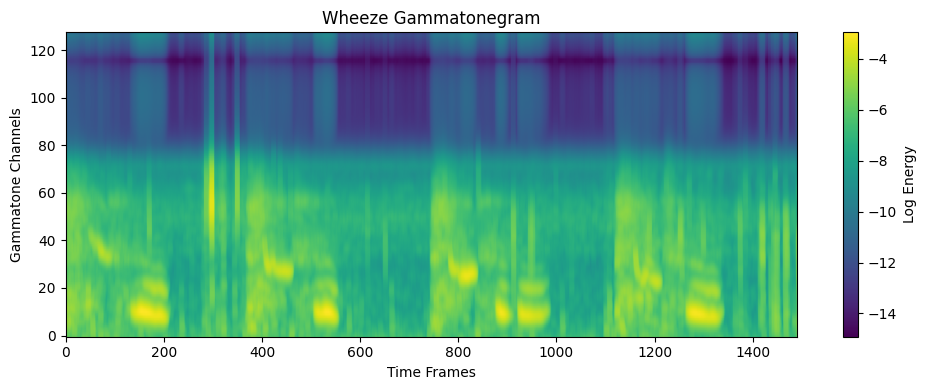

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.imshow(gammatonegram_db, aspect='auto', origin='lower')
plt.colorbar(label='Log Energy')
plt.xlabel("Time Frames")
plt.ylabel("Gammatone Channels")
plt.title("Wheeze Gammatonegram")
plt.tight_layout()
plt.show()

Audio length: (240000,)
Sample rate: 16000
Gammatonegram shape: (64, 1498)
GFCC shape: (13, 1498)


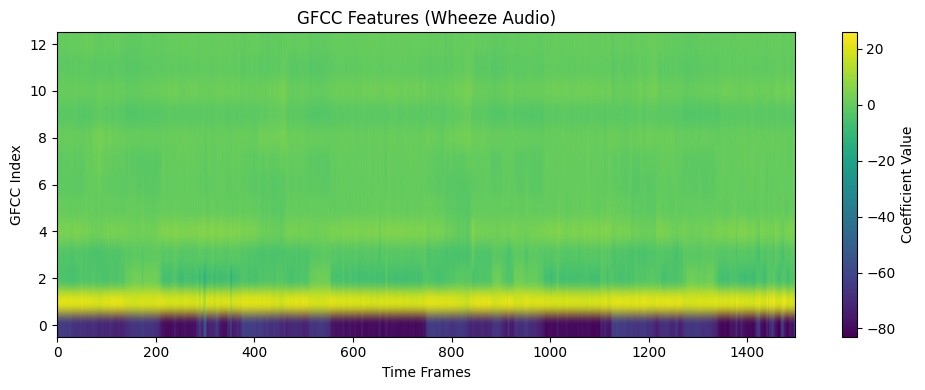

In [28]:
import numpy as np
import librosa
from scipy.fftpack import dct
from gammatone.gtgram import gtgram

audio_path = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count\steth_20181001_11_01_50.wav"

# Load mono audio, resample to 16kHz (recommended)
y, sr = librosa.load(audio_path, sr=16000, mono=True)

print("Audio length:", y.shape)
print("Sample rate:", sr)

window_time = 0.025   # 25 ms
hop_time = 0.010      # 10 ms
num_filters = 64      # Gammatone channels
min_freq = 50         # Lower frequency bound
num_gfcc = 13         # Number of GFCCs

gtg = gtgram(
    y,
    sr,
    window_time,
    hop_time,
    num_filters,
    min_freq
)

print("Gammatonegram shape:", gtg.shape)

log_gtg = np.log(gtg + 1e-10)

gfcc = dct(log_gtg, type=2, axis=0, norm='ortho')

# Keep first N coefficients
gfcc = gfcc[:num_gfcc, :]

print("GFCC shape:", gfcc.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.imshow(gfcc, aspect='auto', origin='lower')
plt.colorbar(label="Coefficient Value")
plt.xlabel("Time Frames")
plt.ylabel("GFCC Index")
plt.title("GFCC Features (Wheeze Audio)")
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import librosa
from scipy.fftpack import dct
from gammatone.gtgram import gtgram
import pandas as pd

# Load audio
audio_path = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count\steth_20181001_11_01_50.wav"
y, sr = librosa.load(audio_path, sr=16000, mono=True)

# Parameters
window_time = 0.025
hop_time = 0.010
num_filters = 64
min_freq = 50
num_gfcc = 13

# Compute gammatonegram
gtg = gtgram(y, sr, window_time, hop_time, num_filters, min_freq)

# Log compression
log_gtg = np.log(gtg + 1e-10)

# DCT → GFCC
gfcc = dct(log_gtg, axis=0, norm='ortho')
gfcc = gfcc[:num_gfcc, :]

print("GFCC shape:", gfcc.shape)

# Convert to DataFrame
df = pd.DataFrame(gfcc.T)   # transpose so each row = one frame

# Save to CSV
df.to_csv("wheeze_gfcc.csv", index=False)

print("GFCC saved as CSV successfully")

GFCC shape: (13, 1498)
GFCC saved as CSV successfully


In [33]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

import librosa
from scipy.fftpack import dct

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb
from gammatone.gtgram import gtgram


# =============================================================================
# CONFIGURATION
# =============================================================================

BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"

WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

OUT_TRAIN = "csv_train_gfcc"
OUT_TEST = "csv_test_gfcc"

os.makedirs(OUT_TRAIN, exist_ok=True)
os.makedirs(OUT_TEST, exist_ok=True)

# Audio
SR = 16000
WIN_DUR = 0.025
HOP_DUR = 0.010

# GFCC
GFCC_FILTERS = 64
GFCC_COEFFS = 13
GFCC_MIN_FREQ = 50


# =============================================================================
# FILE PAIRING
# =============================================================================

wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

pairs = [(wav_stems[k], txt_stems[k]) for k in wav_stems if k in txt_stems]

train_pairs, test_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)


# =============================================================================
# LABEL UTILITIES
# =============================================================================

def parse_audacity_labels(txt_path):

    labels = []

    with open(txt_path) as f:
        for line in f:
            p = line.strip().split('\t')

            if len(p) == 3:
                try:
                    s = float(p[0])
                    e = float(p[1])

                    lab = 1 if 'Wheeze' in p[2] else 0

                    labels.append((s, e, lab))

                except ValueError:
                    pass

    return labels


def wheeze_overlap_ratio(labels, t_start, t_end, min_ratio=0.4):

    overlap = 0.0
    dur = t_end - t_start

    for s, e, lab in labels:
        if lab == 1:
            overlap += max(0, min(e, t_end) - max(s, t_start))

    return 1 if (overlap / dur) >= min_ratio else 0


def enforce_min_wheeze_duration(labels, min_len=10):

    labels = labels.copy()
    n = len(labels)
    i = 0

    while i < n:
        if labels[i] == 1:
            start = i

            while i < n and labels[i] == 1:
                i += 1

            end = i

            if (end - start) < min_len:
                labels[start:end] = 0
        else:
            i += 1

    return labels


def fill_short_zero_gaps(labels, max_gap=4):

    labels = labels.copy()
    n = len(labels)
    i = 0

    while i < n:

        if labels[i] == 0:
            start = i

            while i < n and labels[i] == 0:
                i += 1

            end = i

            if start > 0 and end < n:
                if labels[start-1] == 1 and labels[end] == 1:
                    if (end - start) <= max_gap:
                        labels[start:end] = 1
        else:
            i += 1

    return labels


# =============================================================================
# GFCC FEATURE EXTRACTION
# =============================================================================

def extract_per_file(wav_path, txt_path):

    audio, _ = librosa.load(wav_path, sr=SR)

    labels = parse_audacity_labels(txt_path)

    # ---------------- Gammatonegram ----------------

    gtg = gtgram(
        audio,
        SR,
        WIN_DUR,
        HOP_DUR,
        GFCC_FILTERS,
        GFCC_MIN_FREQ
    )

    log_gtg = np.log(gtg + 1e-10)

    gfcc = dct(log_gtg, axis=0, norm='ortho')
    gfcc = gfcc[:GFCC_COEFFS, :]

    rows = []

    n_frames = gfcc.shape[1]

    for i in range(n_frames):

        t_start = i * HOP_DUR
        t_end = t_start + WIN_DUR

        label = wheeze_overlap_ratio(labels, t_start, t_end)

        row = [
            Path(wav_path).name,
            t_start,
            *gfcc[:, i],
            label
        ]

        rows.append(row)

    columns = (
        ["file", "time_step_s"] +
        [f"GFCC_{i+1}" for i in range(GFCC_COEFFS)] +
        ["label"]
    )

    return pd.DataFrame(rows, columns=columns)


# =============================================================================
# TRAIN SET PROCESSING
# =============================================================================

train_frames = []

print("\nExtracting TRAIN features...")

for wav, txt in train_pairs:

    df = extract_per_file(wav, txt)

    out_file = os.path.join(
        OUT_TRAIN,
        Path(wav).stem + "_train.csv"
    )

    df.to_csv(out_file, index=False)

    train_frames.append(df)

train_df = pd.concat(train_frames, ignore_index=True)


# =============================================================================
# TEST SET PROCESSING
# =============================================================================

test_frames = []

print("\nExtracting TEST features...")

for wav, txt in test_pairs:

    df = extract_per_file(wav, txt)

    test_frames.append(df)

test_df = pd.concat(test_frames, ignore_index=True)


# =============================================================================
# MODEL TRAINING
# =============================================================================

feature_cols = [f"GFCC_{i+1}" for i in range(GFCC_COEFFS)]

X_train = train_df[feature_cols].values
y_train = train_df["label"].values

X_test = test_df[feature_cols].values
y_test = test_df["label"].values


scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)

print("\nTraining XGBoost...")

model.fit(X_train_s, y_train)


# =============================================================================
# PREDICTION + TEMPORAL POST PROCESSING
# =============================================================================

test_df["wheeze_prob"] = model.predict_proba(X_test_s)[:, 1]

test_df["predicted_label_raw"] = (
    test_df["wheeze_prob"] > 0.47
).astype(int)



Extracting TRAIN features...

Extracting TEST features...

Training XGBoost...


In [34]:
def enforce_min_wheeze_duration(labels, min_len=10):
    labels = labels.copy()
    n = len(labels)
    i = 0
    while i < n:
        if labels[i] == 1:
            start = i
            while i < n and labels[i] == 1:
                i += 1
            end = i
            if (end - start) < min_len:
                labels[start:end] = 0
        else:
            i += 1
    return labels


def fill_short_zero_gaps(labels, max_gap=4):
    labels = labels.copy()
    n = len(labels)
    i = 0
    while i < n:
        if labels[i] == 0:
            start = i
            while i < n and labels[i] == 0:
                i += 1
            end = i
            if start > 0 and end < n:
                if labels[start - 1] == 1 and labels[end] == 1:
                    if (end - start) <= max_gap:
                        labels[start:end] = 1
        else:
            i += 1
    return labels

final_preds = []

for fname, df_f in test_df.groupby("file"):
    preds = df_f["predicted_label_raw"].values

    # preds = enforce_min_wheeze_duration(preds, min_len=4)
    preds = enforce_min_wheeze_duration(preds, min_len=4)

    # Fill short zero gaps (<= 40 ms)
    preds = fill_short_zero_gaps(preds, max_gap=4)
    
    # Minimum wheeze duration (>= 100 ms)
    preds = enforce_min_wheeze_duration(preds, min_len=15)

    # NEW BIAS: suppress segments without low-peak frames
    # preds = suppress_segments_without_low_peaks(preds,peaks,amp,peak_thresh=4,amp_thresh=5)


    # Re-enforce duration (robustness)
    # preds = enforce_min_wheeze_duration(preds, min_len=10)

    final_preds.append(pd.Series(preds, index=df_f.index))

test_df["predicted_label"] = pd.concat(final_preds).sort_index()

for fname, df_f in test_df.groupby("file"):
    out = os.path.join(OUT_TEST, Path(fname).stem + "_test.csv")
    df_f.to_csv(out, index=False)

# =============================================================================
# METRICS
# =============================================================================
print(classification_report(y_test, test_df["predicted_label"],
                            target_names=["Normal", "Wheeze"]))
print("Confusion Matrix:\n",
      confusion_matrix(y_test, test_df["predicted_label"]))

print("\nDONE")

              precision    recall  f1-score   support

      Normal       0.63      0.80      0.71     10969
      Wheeze       0.86      0.73      0.79     18991

    accuracy                           0.76     29960
   macro avg       0.75      0.77      0.75     29960
weighted avg       0.78      0.76      0.76     29960

Confusion Matrix:
 [[ 8798  2171]
 [ 5119 13872]]

DONE
